<a href="https://colab.research.google.com/github/BHOOMIJ256/Study_Strategy_Optimizer_and_Recommendation/blob/main/Student_Study_Strategy_Optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statment** ⁉

In Today's Educational system, students often struggle to optimize their study strategies due to the lack of personalized guidance tailored to their unique academic strengths, weaknesses, and time constraints.This challenge is particularly pronounced when juggling multiple subjects, limited resources, and varying levels of parental support and test preparation.

Traditional study plans are typically generalized and fail to account for individual learning patterns, leading to suboptimal performance and wasted effort. Furthermore, factors such as weak subject areas, test preparation effectiveness, and available study hours are not adequately analyzed or utilized to maximize academic outcomes.

# **Project Objective: Study Strategy Optimizer and Recommendations**⌛

The Student Study Strategy Optimizer aims to bridge this gap by leveraging data science and deep learning to create a personalized study strategy for each student. By analyzing historical performance data, demographic factors, and study habits, this solution will:

1. Identify weak subjects that require additional focus.
2. Recommend an optimal allocation of study hours for each subject based on available student data.
3. Suggest necessary guidelines and tips for enhanced and better outcomes.



# **Understanding and Reading the Dataset**

In [1]:
import pandas as pd

data = pd.read_csv('Student_performance_10k.csv')
data

,roll_no,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,science_score,total_score,grade
0,std-01,male,group D,some college,1.0,1.0,89,38.0,85.0,26.0,238.0,C
1,std-02,male,group B,high school,1.0,0.0,65,100.0,67.0,96.0,328.0,A
2,std-03,male,group C,master's degree,1.0,0.0,10,99.0,97.0,58.0,264.0,B
3,std-04,male,group D,some college,1.0,1.0,22,51.0,41.0,84.0,198.0,D
4,std-05,male,group C,some college,0.0,1.0,26,58.0,64.0,65.0,213.0,C
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,std-9996,female,group C,some college,1.0,0.0,78,60.0,46.0,58.0,242.0,C
9996,std-9997,female,group C,bachelor's degree,1.0,0.0,37,92.0,99.0,73.0,301.0,B
9997,std-9998,female,group B,associate's degree,1.0,1.0,70,71.0,100.0,90.0,331.0,A
9998,std-9999,female,group B,some high school,1.0,0.0,87,60.0,100.0,89.0,336.0,A


In [2]:
#Start Row Values

data.head()

,roll_no,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,science_score,total_score,grade
0,std-01,male,group D,some college,1.0,1.0,89,38.0,85.0,26.0,238.0,C
1,std-02,male,group B,high school,1.0,0.0,65,100.0,67.0,96.0,328.0,A
2,std-03,male,group C,master's degree,1.0,0.0,10,99.0,97.0,58.0,264.0,B
3,std-04,male,group D,some college,1.0,1.0,22,51.0,41.0,84.0,198.0,D
4,std-05,male,group C,some college,0.0,1.0,26,58.0,64.0,65.0,213.0,C


In [3]:
#Last Row Values

data.tail()

,roll_no,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,science_score,total_score,grade
9995,std-9996,female,group C,some college,1.0,0.0,78,60.0,46.0,58.0,242.0,C
9996,std-9997,female,group C,bachelor's degree,1.0,0.0,37,92.0,99.0,73.0,301.0,B
9997,std-9998,female,group B,associate's degree,1.0,1.0,70,71.0,100.0,90.0,331.0,A
9998,std-9999,female,group B,some high school,1.0,0.0,87,60.0,100.0,89.0,336.0,A
9999,std-10000,female,group B,high school,1.0,0.0,31,89.0,93.0,80.0,293.0,B


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   roll_no                      9999 non-null   object 
 1   gender                       9982 non-null   object 
 2   race_ethnicity               9977 non-null   object 
 3   parental_level_of_education  9978 non-null   object 
 4   lunch                        9976 non-null   float64
 5   test_preparation_course      9977 non-null   float64
 6   math_score                   9976 non-null   object 
 7   reading_score                9975 non-null   float64
 8   writing_score                9976 non-null   float64
 9   science_score                9977 non-null   float64
 10  total_score                  9981 non-null   float64
 11  grade                        9997 non-null   object 
dtypes: float64(6), object(6)
memory usage: 937.6+ KB


In [5]:
data.describe()

,lunch,test_preparation_course,reading_score,writing_score,science_score,total_score
count,9976.000000,9977.000000,9975.000000,9976.000000,9977.000000,9981.000000
mean,0.644246,0.388694,70.125915,71.415798,66.063045,264.740908
std,0.478765,0.487478,19.026245,18.245360,19.324331,42.304858
min,0.000000,0.000000,17.000000,10.000000,9.000000,89.000000
25%,0.000000,0.000000,57.000000,59.000000,53.000000,237.000000
50%,1.000000,0.000000,71.000000,72.500000,67.000000,268.000000
75%,1.000000,1.000000,85.000000,85.000000,81.000000,294.000000
max,1.000000,1.000000,100.000000,100.000000,100.000000,383.000000


In [6]:
#unique values in all features of the dataset

data.nunique()

,0
roll_no,9999
gender,5
race_ethnicity,11
parental_level_of_education,6
lunch,2
test_preparation_course,2
math_score,99
reading_score,84
writing_score,91
science_score,92


# **Data Cleaning and Preprocessing**

In [7]:
#Checking for null values

data.isnull()

,roll_no,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,science_score,total_score,grade
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
#Sum of null values columnwise

data.isnull().sum()

,0
roll_no,1
gender,18
race_ethnicity,23
parental_level_of_education,22
lunch,24
test_preparation_course,23
math_score,24
reading_score,25
writing_score,24
science_score,23


In [9]:
#Checking for Duplicate Values

data.duplicated().sum()

0

In [10]:
#Converting Float to Numeric Values for better interpretablity

for col in ["math_score", "reading_score", "writing_score", "science_score"]:
    data[col] = pd.to_numeric(data[col], errors='coerce')




In [11]:
#Handling missing values by imputing through mean,median or mode
#Handling numeric columns by mean or median
#Handling Categorical columns by mode

data.fillna({
"gender": data['gender'].mode()[0],
"race_ethnicity": data['race_ethnicity'].mode()[0],
"parental_level_of_education": data['parental_level_of_education'].mode()[0],
"lunch": data['lunch'].median(),
"test_preparation_course": data['test_preparation_course'].median(),
"math_score":data['math_score'].mean(),
"reading_score": data["reading_score"].mean(),
"writing_score": data["writing_score"].mean(),
"science_score": data["science_score"].mean(),
"total_score": data["total_score"].mean(),
"grade":data['grade'].mode()[0],
},inplace = True)



#Ensuring the Consistency of Total Score
data['total_score'] = (data['math_score'] + data['reading_score'] + data['writing_score'] + data['science_score'])


#Returning the cleaned dataset info
data_info_cleaned = data.info()
data_head_cleaned = data.head()

data_info_cleaned, data_head_cleaned


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   roll_no                      9999 non-null   object 
 1   gender                       10000 non-null  object 
 2   race_ethnicity               10000 non-null  object 
 3   parental_level_of_education  10000 non-null  object 
 4   lunch                        10000 non-null  float64
 5   test_preparation_course      10000 non-null  float64
 6   math_score                   10000 non-null  float64
 7   reading_score                10000 non-null  float64
 8   writing_score                10000 non-null  float64
 9   science_score                10000 non-null  float64
 10  total_score                  10000 non-null  float64
 11  grade                        10000 non-null  object 
dtypes: float64(7), object(5)
memory usage: 937.6+ KB


(None,
   roll_no gender race_ethnicity parental_level_of_education  lunch  \
 0  std-01   male        group D                some college    1.0   
 1  std-02   male        group B                 high school    1.0   
 2  std-03   male        group C             master's degree    1.0   
 3  std-04   male        group D                some college    1.0   
 4  std-05   male        group C                some college    0.0   
 
    test_preparation_course  math_score  reading_score  writing_score  \
 0                      1.0        89.0           38.0           85.0   
 1                      0.0        65.0          100.0           67.0   
 2                      0.0        10.0           99.0           97.0   
 3                      1.0        22.0           51.0           41.0   
 4                      1.0        26.0           58.0           64.0   
 
    science_score  total_score grade  
 0           26.0        238.0     C  
 1           96.0        328.0     A  
 2      

# **Exploratory Data Analysis**

In [12]:
data.columns

Index(['roll_no', 'gender', 'race_ethnicity', 'parental_level_of_education',
       'lunch', 'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'science_score', 'total_score', 'grade'],
      dtype='object')

In [13]:
data

,roll_no,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,science_score,total_score,grade
0,std-01,male,group D,some college,1.0,1.0,89.0,38.0,85.0,26.0,238.0,C
1,std-02,male,group B,high school,1.0,0.0,65.0,100.0,67.0,96.0,328.0,A
2,std-03,male,group C,master's degree,1.0,0.0,10.0,99.0,97.0,58.0,264.0,B
3,std-04,male,group D,some college,1.0,1.0,22.0,51.0,41.0,84.0,198.0,D
4,std-05,male,group C,some college,0.0,1.0,26.0,58.0,64.0,65.0,213.0,C
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,std-9996,female,group C,some college,1.0,0.0,78.0,60.0,46.0,58.0,242.0,C
9996,std-9997,female,group C,bachelor's degree,1.0,0.0,37.0,92.0,99.0,73.0,301.0,B
9997,std-9998,female,group B,associate's degree,1.0,1.0,70.0,71.0,100.0,90.0,331.0,A
9998,std-9999,female,group B,some high school,1.0,0.0,87.0,60.0,100.0,89.0,336.0,A


In [14]:
#Count of Roll No's

data['roll_no'].count()

9999

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt


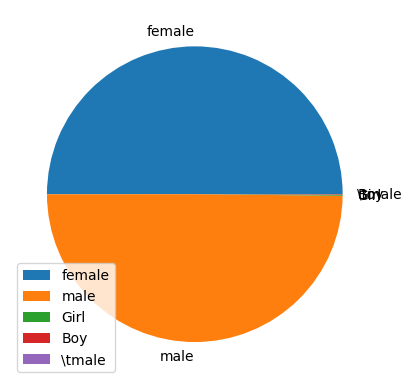

In [16]:
#Count of Gender Male and Female  in pie

plt.pie( data['gender'].value_counts(),labels=data['gender'].value_counts().index)
plt.legend()
plt.show()

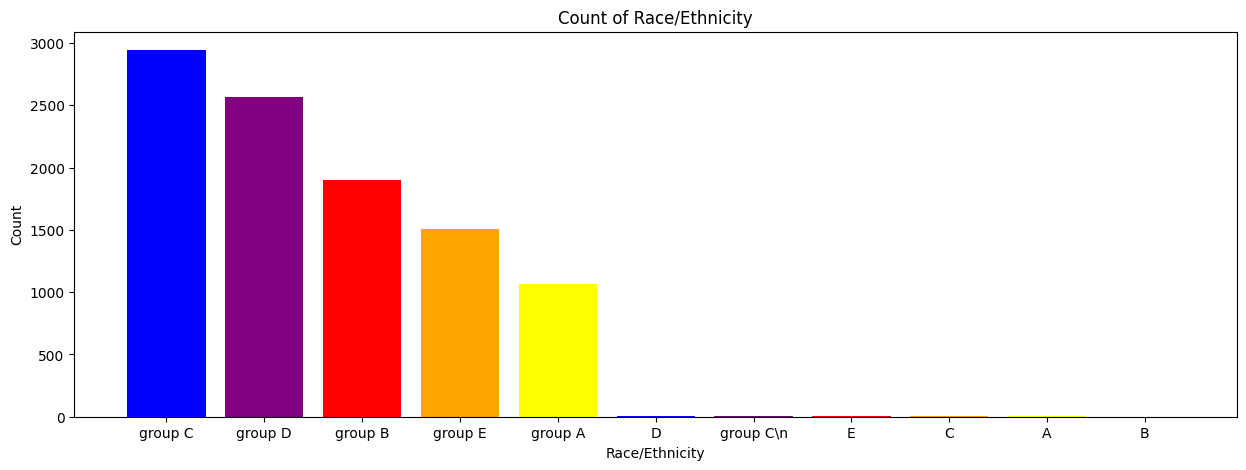

In [17]:
#Count Bar Chart for race ethinicity

figure = plt.figure(figsize =(15,5))
colors = ['blue', 'purple', 'red', 'orange','yellow']
plt.bar(data['race_ethnicity'].value_counts().index, data['race_ethnicity'].value_counts(), color = colors)
plt.xlabel("Race/Ethnicity")
plt.ylabel("Count")
plt.title("Count of Race/Ethnicity")

plt.show()


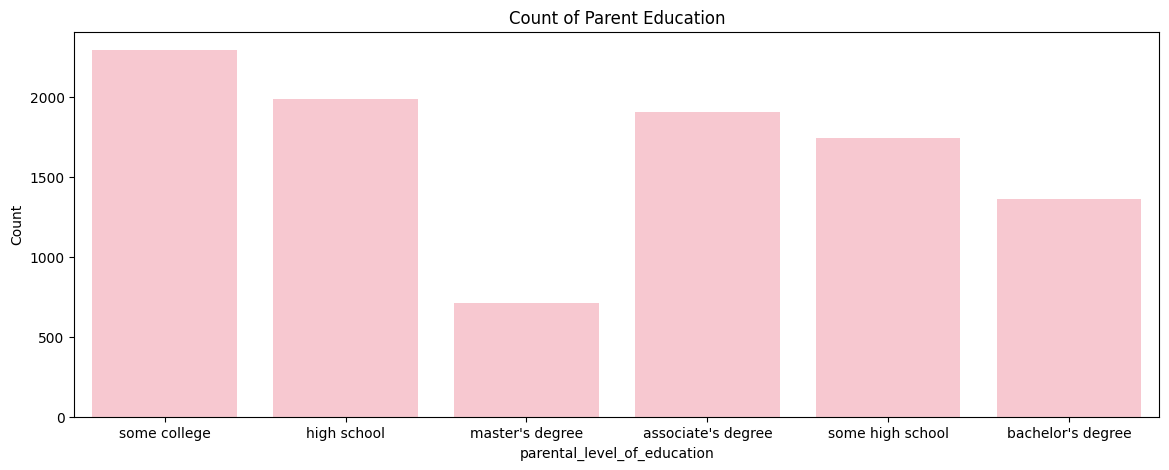

In [18]:
#Bar Chart of parental level of education

figure = plt.figure(figsize =(14,5))
sns.countplot(x = "parental_level_of_education",data=data, color='Pink')
plt.ylabel("Count")
plt.title("Count of Parent Education")
plt.show()


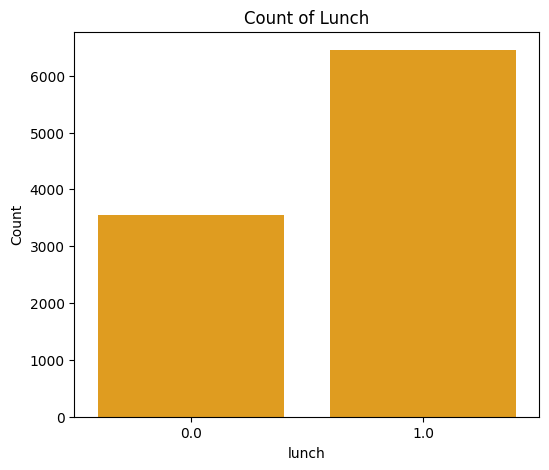

In [19]:
#Distribution of the lunch variable
fig = plt.figure(figsize = (6,5))
sns.countplot(x = "lunch",data=data, color='Orange')
plt.ylabel("Count")
plt.title("Count of Lunch")
plt.show()

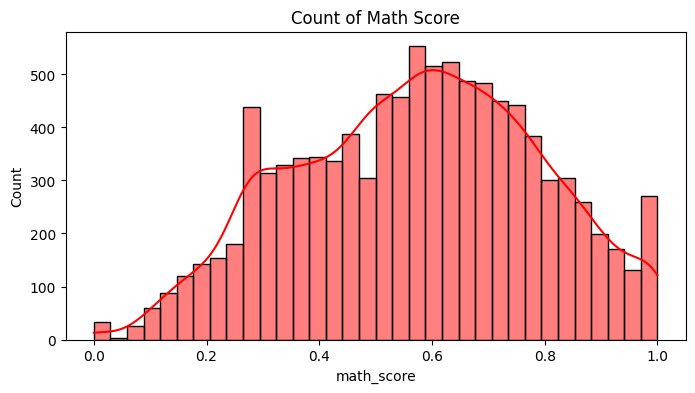

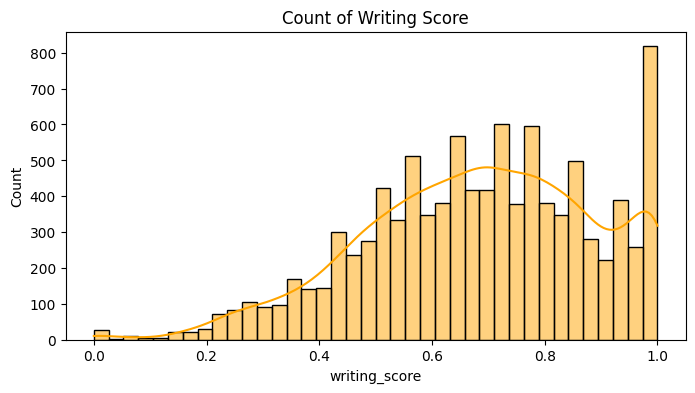

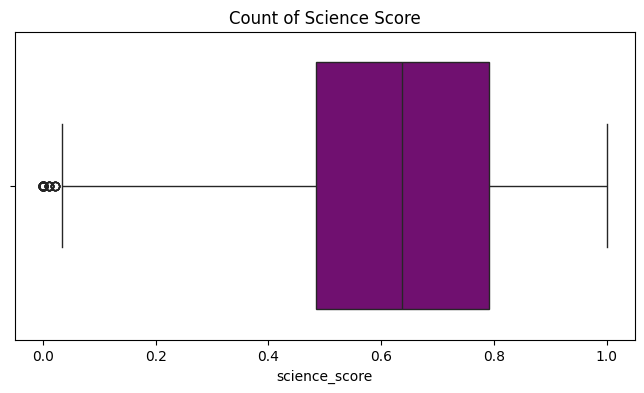

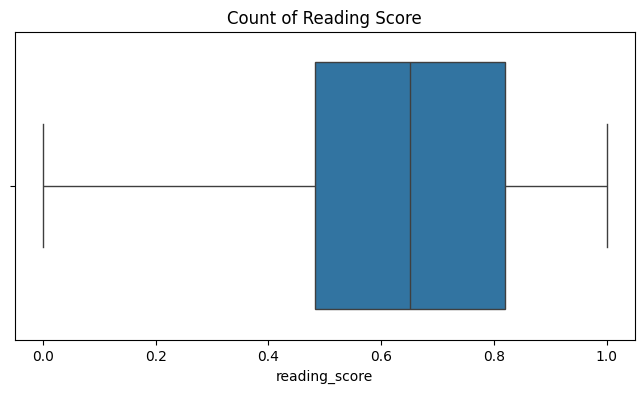

In [52]:
#Histograms on the four variables , math_score, writing_score, science_score and reading_score
figure = plt.figure(figsize =(8,4))
sns.histplot(x = data['math_score'],color ="Red",kde = True)
plt.title("Count of Math Score")
plt.show()

figure = plt.figure(figsize =(8,4))
sns.histplot(x =data['writing_score'],color ="Orange",kde = True)
plt.title("Count of Writing Score")
plt.show()


figure = plt.figure(figsize =(8,4))
sns.boxplot(x =data['science_score'],color ="Purple")
plt.title("Count of Science Score")
plt.show()

figure = plt.figure(figsize =(8,4))
sns.boxplot(x =data['reading_score'])
plt.title("Count of Reading Score")
plt.show()

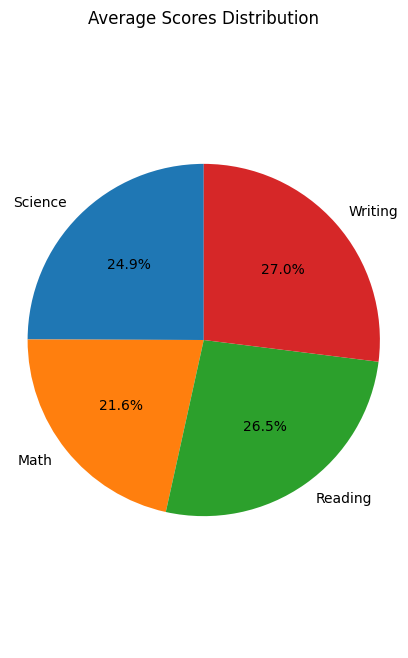

In [21]:
# Prepare data for the pie chart
scores = {
    'Science': data['science_score'].mean(),
    'Math': data['math_score'].mean(),
    'Reading': data['reading_score'].mean(),
    'Writing': data['writing_score'].mean()
}

# Create the pie chart
plt.figure(figsize=(5, 8))  # Adjust figure size as needed
plt.pie(scores.values(), labels=scores.keys(), autopct='%1.1f%%', startangle=90)
plt.title('Average Scores Distribution')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

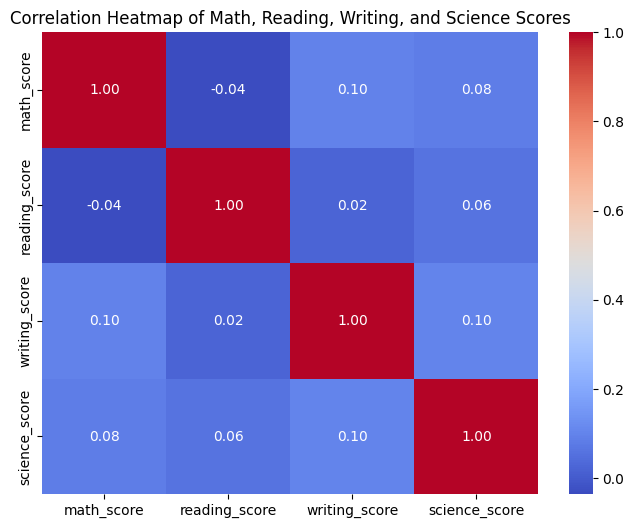

In [22]:
# Select the four variables for the heatmap
variables = ['math_score', 'reading_score', 'writing_score', 'science_score']

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(data[variables].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Math, Reading, Writing, and Science Scores')
plt.show()

Correlation between math score and total score: 0.5781624625230135


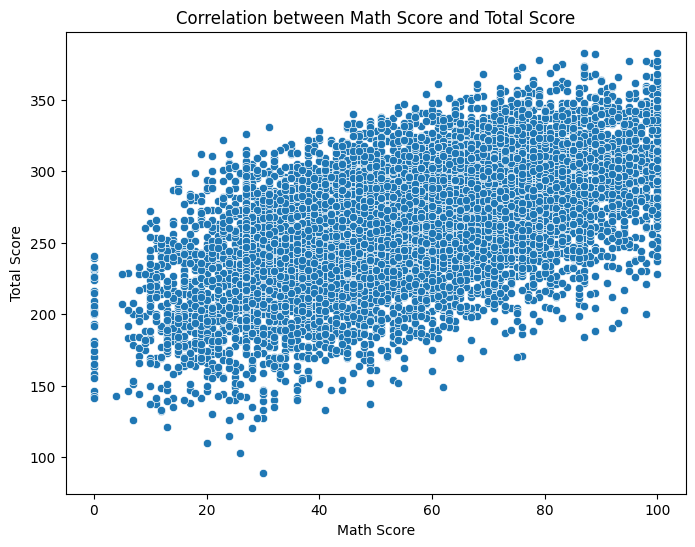

In [23]:
# Calculate the correlation between math score and total score
correlation = data['math_score'].corr(data['total_score'])

# Print the correlation coefficient
print(f"Correlation between math score and total score: {correlation}")

# A scatter plot to visualize the relationship
plt.figure(figsize=(8, 6))
sns.scatterplot(x='math_score', y='total_score', data=data)
plt.title('Correlation between Math Score and Total Score')
plt.xlabel('Math Score')
plt.ylabel('Total Score')
plt.show()

Correlation between total score and science score: 0.5700221811204453


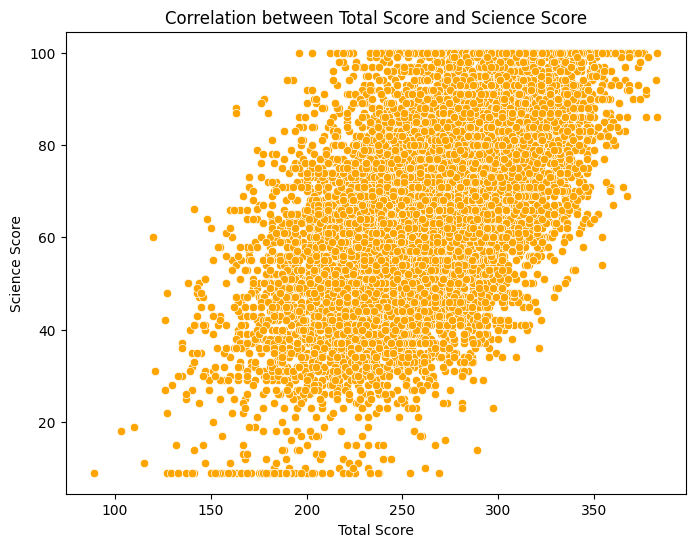

In [24]:
# Calculate the correlation between total score and science score
correlation = data['total_score'].corr(data['science_score'])

# Print the correlation coefficient
print(f"Correlation between total score and science score: {correlation}")

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(8, 6))
sns.scatterplot(x='total_score', y='science_score', data=data, color = "Orange")
plt.title('Correlation between Total Score and Science Score')
plt.xlabel('Total Score')
plt.ylabel('Science Score')
plt.show()

Correlation between total score and reading score is: 0.46893126779481786


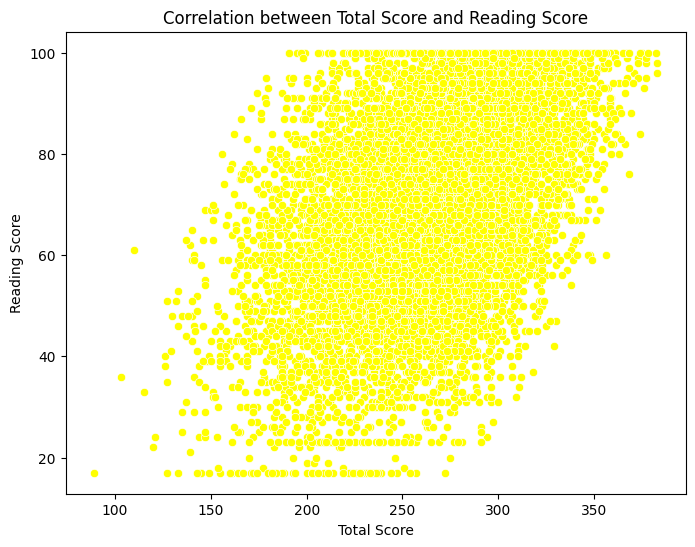

In [25]:
#Calculate the Correlation between total_score and reading_score
correlation = data['total_score'].corr(data['reading_score'])

print("Correlation between total score and reading score is:",correlation)

#Plot scatter plot for the above correlation between total_score and reading_score
fig = plt.figure(figsize =(8,6))
sns.scatterplot(x='total_score', y='reading_score', data=data, color = "yellow")
plt.title('Correlation between Total Score and Reading Score')
plt.xlabel('Total Score')
plt.ylabel('Reading Score')
plt.show()

Correlation between total score and writing score is: 0.5369800858990007


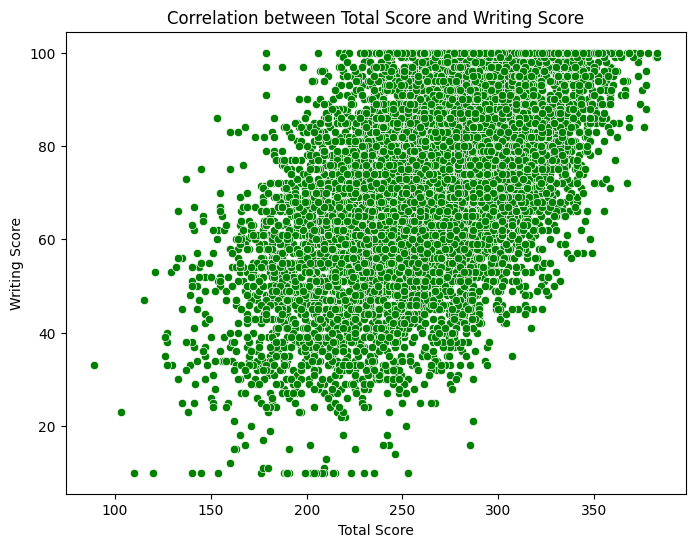

In [26]:
#Calculate the correlation between total score and writing score
correlation = data['total_score'].corr(data['writing_score'])

print("Correlation between total score and writing score is:", correlation)

#Plot the above relationship between toatl_score and writing score
fig = plt.figure(figsize =(8,6))
sns.scatterplot(x='total_score', y='writing_score', data=data, color = "green")
plt.title('Correlation between Total Score and Writing Score')
plt.xlabel('Total Score')
plt.ylabel('Writing Score')
plt.show()

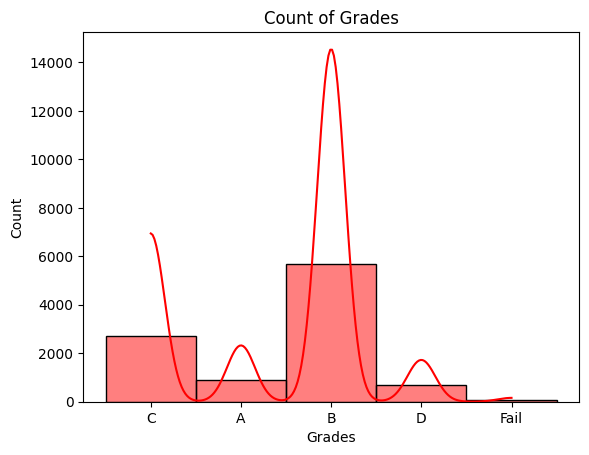

In [27]:

#Display the distribution of grade distribution
sns.histplot(data['grade'],kde= True, color = "red")
plt.title("Count of Grades")
plt.xlabel("Grades")
plt.ylabel("Count")
plt.show()



#**Feature Engineering**

In [28]:
#Drop the roll no column

data = data.drop('roll_no',axis=1)

In [29]:
#Identifying the weak subjects

import pandas as pd
import numpy as np

#Find the subject with the lowest score for each student

data["weak_subject"] = data[["math_score","reading_score","writing_score","science_score"]].idxmin(axis=1)

In [30]:
#Score variability and Average scores
#Calculate the average scores of students

#Calculate the standard deviation of scores across subjects

data['average_score'] = data[['math_score','reading_score','writing_score','science_score']].mean(axis=1)
data["score_variability"] = data[["math_score","reading_score","writing_score","science_score"]].std(axis=1)

In [31]:
# Compute preparation effectiveness

data['prep_effectiveness'] = data["average_score"] / (data['test_preparation_course'] + 1)

In [32]:
#Label encoding for categorical features
#Gender
#Parental Level of Education

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

data['gender'] = label_encoder.fit_transform(data['gender'])

data['parent_edu_encoded'] = label_encoder.fit_transform(data['parental_level_of_education'])



In [33]:
#Ensuring total score

data['total_score'] = data['math_score'] + data['reading_score'] + data['writing_score'] + data['science_score']

#Calculate relative scores

data['relative_math_score'] = data['math_score'] / data['total_score']
data['relative_reading_score'] = data['reading_score'] / data['total_score']
data['relative_writing_score'] = data['writing_score'] / data['total_score']
data['relative_science_score'] = data['science_score'] / data['total_score']

In [34]:

#Key Performance Indicators

high_threshold = data['total_score'].quantile(0.75)
low_threshold = data['total_score'].quantile(0.25)

data['high_performance'] = data['total_score'].apply(lambda x: 1 if x > high_threshold else 0)
data['low_performance'] = data['total_score'].apply(lambda x: 1 if x < low_threshold else 0)

In [35]:

#Interaction between test preparation and weak subject

data['prep_weak_subject'] = data.apply(lambda row: f"{row['test_preparation_course']}_{row['weak_subject']}", axis=1)

In [36]:
#Scaling numeric column to scale

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

numeric_columns =['math_score','reading_score','writing_score','science_score',
                  'average_score', 'score_variability','prep_effectiveness',
                  'total_score','relative_math_score','relative_science_score',
                  'relative_writing_score','relative_reading_score','test_preparation_course']

scaler = MinMaxScaler()
data[numeric_columns] = scaler.fit_transform(data[numeric_columns])

processed_data = data.head()
processed_data


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,science_score,total_score,...,score_variability,prep_effectiveness,parent_edu_encoded,relative_math_score,relative_reading_score,relative_writing_score,relative_science_score,high_performance,low_performance,prep_weak_subject
0,4,group D,some college,1.0,1.0,0.89,0.253012,0.833333,0.186813,0.506803,...,0.665894,0.188940,4,0.763162,0.197469,0.607803,0.149651,0,0,1.0_science_score
1,4,group B,high school,1.0,0.0,0.65,1.000000,0.633333,0.956044,0.812925,...,0.379122,0.831029,2,0.404430,0.492593,0.315257,0.511879,1,0,0.0_math_score
2,4,group C,master's degree,1.0,0.0,0.10,0.987952,0.966667,0.538462,0.595238,...,0.869527,0.634409,3,0.077304,0.635104,0.627478,0.367757,0,0,0.0_math_score
3,4,group D,some college,1.0,1.0,0.22,0.409639,0.344444,0.824176,0.370748,...,0.534875,0.127496,4,0.226757,0.396459,0.320620,0.771662,0,1,1.0_math_score
4,4,group C,some college,0.0,1.0,0.26,0.493976,0.600000,0.615385,0.421769,...,0.376226,0.150538,4,0.249114,0.426384,0.499351,0.536525,0,1,1.0_math_score


In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

# Save the processed data to a new CSV file
data.to_csv('processed_student_performance.csv', index=False)

#PowerBi can be used to visualize the above processed data

# **Model Development**

In [38]:
#Splitting the features and target variable

target = 'high_performance'
features = numeric_columns + ['parent_edu_encoded']

X = data[features]
y = data[target]

In [39]:
#Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
#Build the Deep Learning Model

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
#Compile the Model

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [42]:
#Train the model

history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2,verbose = 1)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7426 - loss: 0.5568 - val_accuracy: 0.8981 - val_loss: 0.2612
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8941 - loss: 0.2507 - val_accuracy: 0.9150 - val_loss: 0.1937
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9322 - loss: 0.1647 - val_accuracy: 0.9625 - val_loss: 0.1022
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9456 - loss: 0.1273 - val_accuracy: 0.9631 - val_loss: 0.0923
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9564 - loss: 0.1073 - val_accuracy: 0.9656 - val_loss: 0.0780
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9588 - loss: 0.0954 - val_accuracy: 0.9819 - val_loss: 0.0591
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9615 - loss: 0.0860 - val_accuracy: 0.9525 - val_loss: 0.0937
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9612 - loss: 0.0857 - val_accuracy: 0.

# **Model Evaluation & Summary**

In [43]:
#evaluate the model

evaluation = model.evaluate(X_test, y_test)
print(f"Test Loss: {evaluation[0]}, Test Accuracy: {evaluation[1]}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9944 - loss: 0.0171
Test Loss: 0.017289791256189346, Test Accuracy: 0.9955000281333923


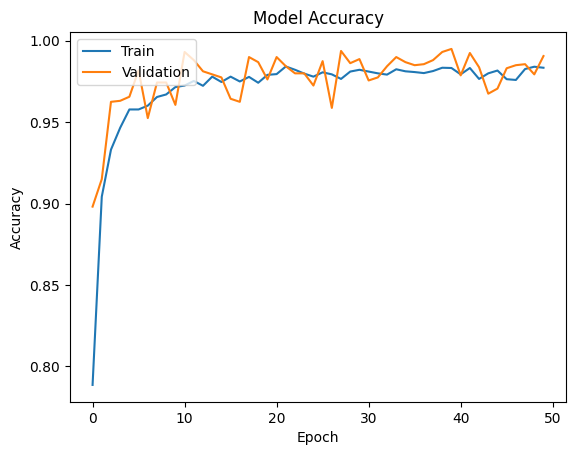

In [44]:
#summarize the history of accuracy

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

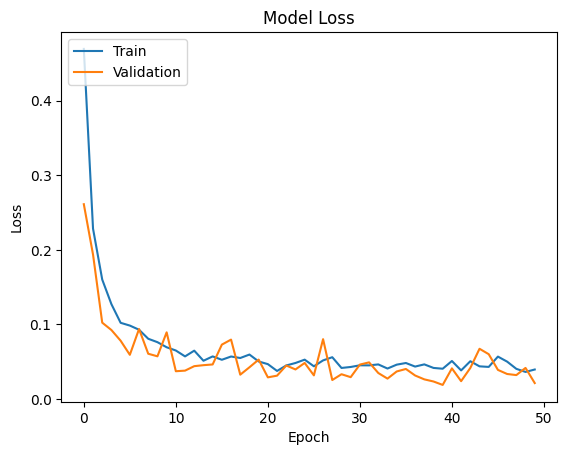

In [45]:
#summarize the history of loss

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

In [46]:
#save the model

model.save('student_performance_model.h5')

# **Study Strategy Prediction On User Input**

In [47]:
#load the trained Model

from tensorflow.keras.models import load_model

loaded_model = load_model('student_performance_model.h5')



In [48]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

def predict_study_strategy(input_data):
    """
    Function to predict study strategy based on user input.
    :param input_data: Dictionary of feature values.
    :return: Prediction (High performance: 1, Low performance: 0)
    """
    input_df = pd.DataFrame([input_data])

    # Ensure feature scaling
    scaler = MinMaxScaler()
    input_df[numeric_columns] = scaler.fit_transform(input_df[numeric_columns])

    # Make prediction
    prediction = model.predict(input_df)
    return int(prediction[0][0] > 0.5)

# Example user input
user_input = {
    'math_score': 70,
    'reading_score': 80,
    'writing_score': 65,
    'science_score': 75,
    'test_preparation_course': 'completed',
    'parental_edu_encoded':"Bachelor's Degree",
}


#preprocessing the raw inputs

user_input['test_preparation_course'] = 1 if user_input['test_preparation_course'] == 'completed' else 0
label_encoder = LabelEncoder()
user_input['parental_edu_encoded'] = label_encoder.fit_transform([user_input['parental_edu_encoded']])[0]

user_input['average_score'] = np.mean([user_input['math_score'], user_input['reading_score'], user_input['writing_score'], user_input['science_score']])
user_input['score_variability'] = np.std([user_input['math_score'], user_input['reading_score'], user_input['writing_score'], user_input['science_score']])
user_input['prep_effectiveness'] = user_input['average_score'] / (user_input['test_preparation_course'] + 1)
user_input['total_score'] = sum([user_input['math_score'], user_input['reading_score'], user_input['writing_score'], user_input['science_score']])

user_input['relative_math_score'] = user_input['math_score'] / user_input['total_score']
user_input['relative_reading_score'] = user_input['reading_score'] / user_input['total_score']
user_input['relative_writing_score'] = user_input['writing_score'] / user_input['total_score']
user_input['relative_science_score'] = user_input['science_score'] / user_input['total_score']

# Predicting for the user input
study_strategy_prediction = predict_study_strategy(user_input)
print(f"Predicted Study Strategy: {'High Performance' if study_strategy_prediction == 1 else 'Low Performance'}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predicted Study Strategy: Low Performance


# **Time Allocation and  Personalized Recommendations**

In [49]:

def calculate_study_allocation(row,total_study_hours):
  #start with equal time allocation
  allocation = {
      'Math': 0.25,
      'Reading': 0.25,
      'Writing': 0.25,
      'Science': 0.25
  }
  #Adjust allocation based on weak subjects
  if row['weak_subject'] == 'math_score':
    allocation['Math'] += 0.1
  elif row['weak_subject'] == 'reading_score':
    allocation['Reading'] += 0.1
  elif row['weak_subject'] == 'writing_score':
    allocation['Writing'] += 0.1
  elif row['weak_subject'] == 'science_score':
    allocation['Science'] += 0.1


  #Normalize allocation so the total is 1
  total_allocation = sum(allocation.values())
  for subject in allocation:
    allocation[subject] /= total_allocation

  #Multiply by total study hours to get final allocation
  for subject in allocation:
    allocation[subject] *= total_study_hours
    allocation[subject] = round(allocation[subject])

  return allocation

total_study_hours = 8
example_student = data.iloc[0]
study_allocation = calculate_study_allocation(example_student, total_study_hours)
print("Study Allocation:",study_allocation)



Study Allocation: {'Math': 2, 'Reading': 2, 'Writing': 2, 'Science': 3}


In [50]:
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()

def generate_recommendations(row):
  recommendations = []

#Weak subject recommendation
  recommendations.append(f"Focus more on {row['weak_subject']} for better performance.")

#Test Preparation
  if row['test_preparation_course'] == 0:
    recommendations.append("Consider completing a test preparation course to boost your scores.")
  else:
    recommendations.append("Great job on completing the test preparation course! Keep up the good work")

#Parental Education insights
  # parental_education = label_encoder.inverse_transform([row['parental_edu_encoded']])[0]
  # recommendations.append(f"Your parent's education level is {parental_education}." "Utilize available resources to bridge any learning gaps.")

  #Subject-specific tips
  if row['relative_math_score'] < 0.2:
    recommendations.append("Spend extra time practicing Math Problems to strengthen your foundation")
  if row['relative_reading_score'] < 0.2:
    recommendations.append("Improve reading comprehension by practicing passages daily.")
  if row['relative_writing_score'] < 0.2:
    recommendations.append("Work on writing skills by summarizing articles or essays.")
  if row['relative_science_score'] < 0.2:
    recommendations.append("Focus on understanding scientific concepts and solving problems")

  return recommendations

recommendations = generate_recommendations(example_student)
print("Recommendations:")
for rec in recommendations:
  print("-",rec)

Recommendations:
- Focus more on science_score for better performance.
- Great job on completing the test preparation course! Keep up the good work
- Improve reading comprehension by practicing passages daily.
- Focus on understanding scientific concepts and solving problems
